In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[2]
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from ucimlrepo import fetch_ucirepo

from bart_playground import ParallelTemperingBART
from experiment import make_fixed100_splits

In [3]:
# Load real4_Concrete
concrete = fetch_ucirepo(id=165)
X = concrete.data.features.values.astype(float)
y = np.asarray(concrete.data.targets).reshape(-1)

# Fixed-100 split (same policy as fixed100_testpoints/experiment.py)
splits = make_fixed100_splits(
    X,
    y,
    n_runs=1,
    n_fixed_test_points=100,
    train_fraction=0.75,
    fixed_test_seed=42,
    base_train_seed=2026,
)
split = splits[0]
X_train, y_train = split["X_train"], split["y_train"]
X_test, y_test = split["X_test_fixed"], split["y_test_fixed"]

print(f"X_train={X_train.shape}, X_test={X_test.shape}, train_seed={split['train_seed']}")

X_train=(697, 8), X_test=(100, 8), train_seed=2026


In [4]:
# default_pt run with fixed temperatures
temperatures = (1, 2, 3, 5, 10, 50)
model = ParallelTemperingBART(
    ndpost=500,
    nskip=100,
    n_trees=100,
    proposal_probs={"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1},
    temperatures=temperatures,
    swap_interval=50,
    random_state=int(split["train_seed"]),
)
model.fit(X_train, y_train, quietly=True)

pred_samples = model.posterior_f(X_test, backtransform=True)
pred_mean = np.mean(pred_samples, axis=1)
rmse = root_mean_squared_error(y_test, pred_mean)
print(f"Temperatures: {temperatures}")
print(f"RMSE (fixed100 test points): {rmse:.6f}")

Temperatures: (1, 2, 3, 5, 10, 50)
RMSE (fixed100 test points): 5.547440


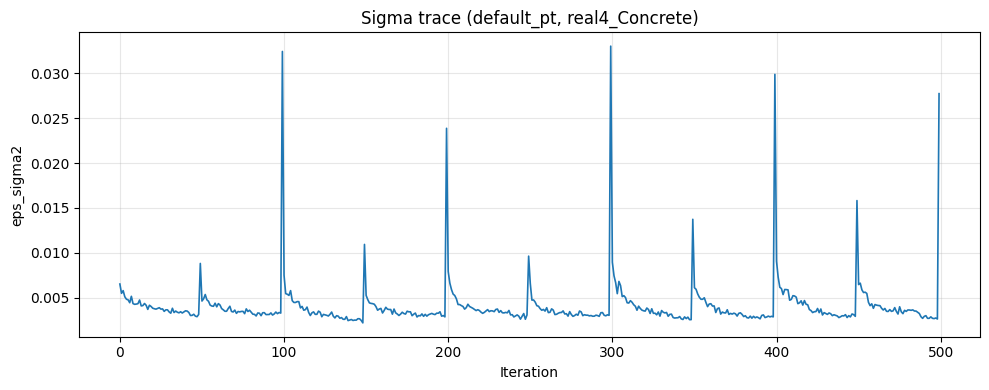

sigma mean=0.004030, sigma std=0.002872


In [5]:
# Sigma trace
sigmas = np.array([float(trace.global_params['eps_sigma2'][0]) for trace in model.trace], dtype=float)

plt.figure(figsize=(10, 4))
plt.plot(sigmas, lw=1.2)
plt.xlabel('Iteration')
plt.ylabel('eps_sigma2')
plt.title('Sigma trace (default_pt, real4_Concrete)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sigma mean={sigmas.mean():.6f}, sigma std={sigmas.std():.6f}")

In [6]:
# default_pt run with fixed temperatures
temperatures = (1, 2, 3, 5, 10, 50)
model = ParallelTemperingBART(
    ndpost=500,
    nskip=100,
    n_trees=100,
    proposal_probs={"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1},
    temperatures=temperatures,
    swap_interval=50,
    random_state=int(split["train_seed"]),
    swap_sigma=False,
)
model.fit(X_train, y_train, quietly=True)

pred_samples = model.posterior_f(X_test, backtransform=True)
pred_mean = np.mean(pred_samples, axis=1)
rmse = root_mean_squared_error(y_test, pred_mean)
print(f"Temperatures: {temperatures}")
print(f"RMSE (fixed100 test points): {rmse:.6f}")

Temperatures: (1, 2, 3, 5, 10, 50)
RMSE (fixed100 test points): 5.121003


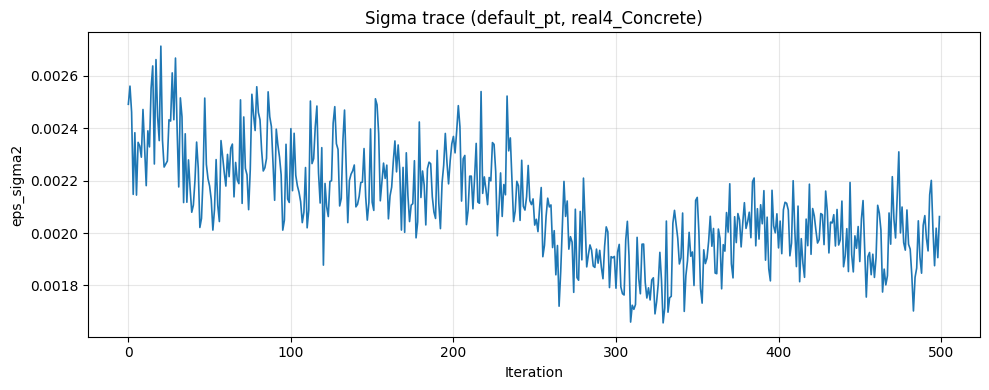

sigma mean=0.002103, sigma std=0.000200


In [7]:
# Sigma trace
sigmas = np.array([float(trace.global_params['eps_sigma2'][0]) for trace in model.trace], dtype=float)

plt.figure(figsize=(10, 4))
plt.plot(sigmas, lw=1.2)
plt.xlabel('Iteration')
plt.ylabel('eps_sigma2')
plt.title('Sigma trace (default_pt, real4_Concrete)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sigma mean={sigmas.mean():.6f}, sigma std={sigmas.std():.6f}")